
# CNT-forest einzel lens: defensible electrostatics + effective forest emission

This notebook upgrades the earlier prototype to a **macro-scale, research-oriented axisymmetric model** with:

- explicit **piecewise dielectric** electrostatics,
- a more realistic **electrode + oxide stack**,
- a **CNT forest macro-emitter** instead of a single isolated tip,
- **effective Fowler–Nordheim (FN)** coupling on the forest canopy,
- automated **boundary-sensitivity** and **mesh-refinement** studies,
- clean markdown equations that render correctly in Jupyter.

## What this notebook is solving

We solve the axisymmetric electrostatic equation with spatially varying permittivity:

$$
\nabla \cdot \left( \varepsilon(r,z)\,\nabla V(r,z) \right) = 0,
$$

which in cylindrical symmetry becomes

$$
\frac{1}{r}\frac{\partial}{\partial r}\!\left(r\,\varepsilon(r,z)\,\frac{\partial V}{\partial r}\right)
+
\frac{\partial}{\partial z}\!\left(\varepsilon(r,z)\,\frac{\partial V}{\partial z}\right)
=0.
$$

The electric field is then obtained from

$$
\mathbf{E}(r,z) = -\nabla V(r,z),
\qquad
E_r = -\frac{\partial V}{\partial r},
\qquad
E_z = -\frac{\partial V}{\partial z}.
$$

## What changed relative to the single-tip notebook

The previous notebook modeled one central CNT-like protrusion. For a **dense CNT forest** occupying most of the aperture, that is not the right emission model.

This notebook therefore uses a **macro / effective multiscale strategy**:

1. **Macro electrostatics**
   - Solve the lens-scale electrostatic problem in an axisymmetric domain.
   - Represent the forest as a **dense conducting emitter region** of radius \(R_{\mathrm{forest}}\) and height \(h_{\mathrm{forest}}\).

2. **Effective forest emission**
   - Sample the **macroscopic normal field** on the forest canopy.
   - Convert that field to an **effective local tip field** using a user-specified forest enhancement factor:
     $$
     F_{\mathrm{eff}}(r) = \beta_{\mathrm{forest,eff}}\,F_{\mathrm{macro}}(r).
     $$
   - Apply Fowler–Nordheim emission on the canopy:
     $$
     J_{\mathrm{FN}}(r)
     =
     \frac{A_{\mathrm{FN}}}{\phi}\,F_{\mathrm{eff}}(r)^2\,
     \exp\!\left[-B_{\mathrm{FN}}\frac{\phi^{3/2}}{F_{\mathrm{eff}}(r)}\right].
     $$

This is **much more appropriate for a dense forest** than treating the source as one isolated nanotube.

## Important scope note

This notebook is designed to produce a **defensible macro-scale electrostatic and effective-emission model**. It is **not** an atomistic or explicit many-CNT simulation, and it does **not yet** trace electron trajectories. That next step can be built directly on the saved fields from this notebook.


In [1]:

import time
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from scipy import sparse
from scipy.sparse.linalg import spsolve, bicgstab, spilu, LinearOperator



## User parameters

These are the main geometry, material, solver, and effective-emission parameters.

### Interpretation of the geometry

- The **bottom plane** at \(z=0\) is the cathode at \(-V_{\mathrm{CNT}}\).
- The CNT source is a **forest region** of radius \(R_{\mathrm{forest}}\) and height \(h_{\mathrm{forest}}\).
- The einzel lens is represented by **three ring electrodes** spanning from the aperture radius \(a_{\mathrm{inner}}\) to the physical outer stack radius \(r_{\mathrm{stack,out}}\).
- The annular stack region between and around those electrodes is filled with **SiO\(_2\)**.
- The computational truncation radius \(R_{\mathrm{outer}}\) is chosen **larger than** the physical stack radius so the outer boundary can still act as a far-field truncation.


In [16]:

# -----------------------------
# Voltages
# -----------------------------
V_CNT = 1500.0        # cathode / forest conductor potential is -V_CNT [V]
V_MID = 20000.0         # middle lens electrode [V]

# -----------------------------
# Lens geometry
# -----------------------------
a_inner = 0.50e-3         # inner aperture radius of the ring electrodes [m]
r_stack_outer = 1.10e-3   # physical outer radius of the electrode + dielectric stack [m]
t_e = 0.10e-3             # electrode thickness [m]
edge_radius = 0.03e-3     # rounded-corner radius for the electrode cross-section [m]

d1 = 0.35e-3              # cathode plane to electrode 1 [m]
d2 = 0.45e-3              # electrode 1 to electrode 2 [m]
d3 = 0.45e-3              # electrode 2 to electrode 3 [m]

# -----------------------------
# Dielectric
# -----------------------------
eps_r_oxide = 3.9         # SiO2 relative permittivity
fill_stack_with_oxide = True

# -----------------------------
# CNT forest macro-emitter model
# -----------------------------
R_forest = 0.42e-3        # forest radius [m], typically most of the aperture
h_forest = 60e-6          # forest height above cathode plane [m]
forest_edge_radius = 20e-6  # optional rounding of the canopy outer corner [m]

# -----------------------------
# Effective forest-emission model
# -----------------------------
work_function_eV = 4.8      # representative CNT work function [eV]
beta_forest_eff = 250.0     # effective field-enhancement factor for the dense forest canopy
tip_areal_density = 5.0e12  # active emitting tips per m^2 on the canopy
tip_apex_radius = 8.0e-9    # effective emitting tip radius [m]
emission_edge_exclusion = 25e-6  # exclude canopy rim from FN sampling [m]

# -----------------------------
# Computational domain
# -----------------------------
R_outer = 1.60e-3         # radial truncation [m]
z_extra = 1.40e-3         # extra axial distance beyond the last electrode [m]

# # -----------------------------
# # Voltages
# # -----------------------------
# V_CNT = 100.0        # cathode / forest conductor potential is -V_CNT [V]
# V_MID = 100.0         # middle lens electrode [V]

# # -----------------------------
# # Lens geometry
# # -----------------------------
# a_inner = 5.0e-6         # inner aperture radius of the ring electrodes [m]
# r_stack_outer = 1.5e-5   # physical outer radius of the electrode + dielectric stack [m]
# t_e = 0.10e-6             # electrode thickness [m]
# edge_radius = 0.03e-6     # rounded-corner radius for the electrode cross-section [m]

# d1 = 1e-6              # cathode plane to electrode 1 [m]
# d2 = 5e-6              # electrode 1 to electrode 2 [m]
# d3 = 5e-6              # electrode 2 to electrode 3 [m]

# # -----------------------------
# # Dielectric
# # -----------------------------
# eps_r_oxide = 3.9         # SiO2 relative permittivity
# fill_stack_with_oxide = True

# # -----------------------------
# # CNT forest macro-emitter model
# # -----------------------------
# R_forest = 3e-6        # forest radius [m], typically most of the aperture
# h_forest = 50e-9          # forest height above cathode plane [m]
# forest_edge_radius = 5e-9  # optional rounding of the canopy outer corner [m]

# # -----------------------------
# # Effective forest-emission model
# # -----------------------------
# work_function_eV = 4.8      # representative CNT work function [eV]
# beta_forest_eff = 250.0     # effective field-enhancement factor for the dense forest canopy
# tip_areal_density = 5.0e12  # active emitting tips per m^2 on the canopy
# tip_apex_radius = 3.0e-9    # effective emitting tip radius [m]
# emission_edge_exclusion = 25e-6  # exclude canopy rim from FN sampling [m]

# # -----------------------------
# # Computational domain
# # -----------------------------
# R_outer = 1.7e-5         # radial truncation [m]
# z_extra = 1.5e-5         # extra axial distance beyond the last electrode [m]

# -----------------------------
# Grids
# -----------------------------
baseline_grid = (301, 701)
mesh_grids = {
    "coarse": (121, 281),
    "medium": (181, 421),
    "fine":   (241, 561),
    "xfine":  (301, 701),   # reduce to (281, 641) if runtime is too high
}

# -----------------------------
# Boundary-study variants
# -----------------------------
boundary_cases = {
    "baseline":    (R_outer, z_extra),
    "larger_r":    (1.25 * R_outer, z_extra),
    "larger_z":    (R_outer, 1.50 * z_extra),
    "larger_both": (1.25 * R_outer, 1.50 * z_extra),
}

# -----------------------------
# Solver controls
# -----------------------------
bicg_tol = 1e-10
bicg_maxiter = 5000
RUN_BICGSTAB_CROSSCHECK = True

# -----------------------------
# Study controls
# -----------------------------
RUN_BOUNDARY_STUDY = True
RUN_MESH_STUDY = True
compare_tail = 0.60e-3  # compare axis observables up to z3_end + compare_tail

# -----------------------------
# Convergence / truncation tolerances
# These are applied to the primary electrostatic observables.
# The FN total current is reported too, but is not used as the main
# pass/fail criterion because it is exponentially sensitive.
# -----------------------------
tol_boundary_axisV_peak = 5e-3
tol_boundary_axis_field_integral = 5e-3
tol_boundary_forest_macroF_mean = 1e-2
tol_boundary_forest_macroF_p95 = 2e-2

tol_mesh_axisV_peak = 1e-2
tol_mesh_axis_field_integral = 1e-2
tol_mesh_forest_macroF_mean = 2e-2
tol_mesh_forest_macroF_p95 = 5e-2


In [17]:

z1_start = d1
z1_end   = z1_start + t_e

z2_start = z1_end + d2
z2_end   = z2_start + t_e

z3_start = z2_end + d3
z3_end   = z3_start + t_e

params = {
    "V_CNT": V_CNT,
    "V_MID": V_MID,
    "a_inner": a_inner,
    "r_stack_outer": r_stack_outer,
    "t_e": t_e,
    "edge_radius": edge_radius,
    "d1": d1,
    "d2": d2,
    "d3": d3,
    "z1_start": z1_start,
    "z1_end": z1_end,
    "z2_start": z2_start,
    "z2_end": z2_end,
    "z3_start": z3_start,
    "z3_end": z3_end,
    "eps_r_oxide": eps_r_oxide,
    "fill_stack_with_oxide": fill_stack_with_oxide,
    "R_forest": R_forest,
    "h_forest": h_forest,
    "forest_edge_radius": forest_edge_radius,
    "work_function_eV": work_function_eV,
    "beta_forest_eff": beta_forest_eff,
    "tip_areal_density": tip_areal_density,
    "tip_apex_radius": tip_apex_radius,
    "emission_edge_exclusion": emission_edge_exclusion,
}

print("Electrode positions:")
print(f"  E1: {z1_start*1e3:.3f} to {z1_end*1e3:.3f} mm")
print(f"  E2: {z2_start*1e3:.3f} to {z2_end*1e3:.3f} mm")
print(f"  E3: {z3_start*1e3:.3f} to {z3_end*1e3:.3f} mm")
print()
print(f"Forest radius = {R_forest*1e3:.3f} mm")
print(f"Forest height = {h_forest*1e6:.1f} µm")
print(f"Physical stack radius = {r_stack_outer*1e3:.3f} mm")
print(f"Computational truncation radius = {R_outer*1e3:.3f} mm")


Electrode positions:
  E1: 0.350 to 0.450 mm
  E2: 0.900 to 1.000 mm
  E3: 1.450 to 1.550 mm

Forest radius = 0.420 mm
Forest height = 60.0 µm
Physical stack radius = 1.100 mm
Computational truncation radius = 1.600 mm



## Geometry construction

### Forest model
The dense CNT forest is represented as a **macro conducting emitter region**:

- radius \(R_{\mathrm{forest}}\),
- height \(h_{\mathrm{forest}}\),
- optional rounded canopy corner.

This captures the **lens-scale boundary condition** seen by the beam without pretending that one nanotube stands in for the whole forest.

### Dielectric model
The SiO\(_2\) region is represented explicitly via \(\varepsilon_r = 3.9\) in the annular stack region outside the aperture:

$$
\varepsilon(r,z) = \varepsilon_0 \,\varepsilon_r(r,z).
$$

The conductors themselves are imposed as **Dirichlet regions**, and the oxide is only assigned in the non-conducting parts of the stack.

### Why this is better
This is much closer to the sketched physical structure than:
- a single CNT tip,
- floating electrodes in vacuum with no padding,
- or a purely homogeneous vacuum model.


In [18]:

def trapz_compat(y, x):
    try:
        return np.trapezoid(y, x)
    except AttributeError:
        return np.trapz(y, x)


def harmonic_mean(a, b):
    denom = a + b
    out = np.zeros_like(a, dtype=float)
    mask = denom > 0
    out[mask] = 2.0 * a[mask] * b[mask] / denom[mask]
    return out


def rounded_rect_mask(RR, ZZ, r0, r1, z0, z1, rad):
    '''
    Rounded rectangle in the (r,z) plane.
    '''
    cx = 0.5 * (r0 + r1)
    cz = 0.5 * (z0 + z1)
    hx = 0.5 * (r1 - r0)
    hz = 0.5 * (z1 - z0)

    rad = max(0.0, min(rad, hx, hz))

    qx = np.abs(RR - cx) - (hx - rad)
    qz = np.abs(ZZ - cz) - (hz - rad)

    sdf = np.sqrt(np.maximum(qx, 0.0)**2 + np.maximum(qz, 0.0)**2)           + np.minimum(np.maximum(qx, qz), 0.0) - rad
    return sdf <= 0.0


def forest_mask_macro(RR, ZZ, R_forest, h_forest, rc):
    '''
    Forest macro-emitter region:
    flat-bottom conductor attached to the cathode plane,
    with an optional rounded canopy outer corner.
    '''
    if rc <= 0.0:
        return (RR <= R_forest) & (ZZ <= h_forest)

    rc = min(rc, R_forest, h_forest)
    vertical = (RR <= R_forest) & (ZZ <= max(h_forest - rc, 0.0))
    top_inner = (RR <= max(R_forest - rc, 0.0)) & (ZZ <= h_forest)
    corner = (
        ((RR - (R_forest - rc))**2 + (ZZ - (h_forest - rc))**2 <= rc**2)
        & (RR >= max(R_forest - rc, 0.0))
        & (ZZ >= max(h_forest - rc, 0.0))
    )
    return vertical | top_inner | corner


def build_geometry(r, z, params):
    RR, ZZ = np.meshgrid(r, z, indexing="ij")
    Nr, Nz = RR.shape

    eps_rel = np.ones((Nr, Nz), dtype=float)
    material_id = np.zeros((Nr, Nz), dtype=np.int8)   # 0 vacuum, 1 oxide
    is_dir = np.zeros((Nr, Nz), dtype=bool)
    V_bc = np.zeros((Nr, Nz), dtype=float)
    conductor_id = np.zeros((Nr, Nz), dtype=np.int8)  # 0 none, 1 cathode/forest, 2 e1, 3 e2, 4 e3

    # Bottom cathode plane
    is_dir[:, 0] = True
    V_bc[:, 0] = -params["V_CNT"]
    conductor_id[:, 0] = 1

    # Outer and top truncation boundaries
    is_dir[-1, :] = True
    V_bc[-1, :] = 0.0

    is_dir[:, -1] = True
    V_bc[:, -1] = 0.0

    # Annular SiO2 stack region outside the aperture
    if params["fill_stack_with_oxide"]:
        stack_oxide = (
            (RR >= params["a_inner"])
            & (RR <= params["r_stack_outer"])
            & (ZZ >= 0.0)
            & (ZZ <= params["z3_end"])
        )
        material_id[stack_oxide] = 1
        eps_rel[stack_oxide] = params["eps_r_oxide"]

    # Dense CNT forest macro-emitter
    forest_mask = forest_mask_macro(
        RR, ZZ,
        params["R_forest"],
        params["h_forest"],
        params["forest_edge_radius"]
    )
    is_dir[forest_mask] = True
    V_bc[forest_mask] = -params["V_CNT"]
    conductor_id[forest_mask] = 1
    material_id[forest_mask] = 0
    eps_rel[forest_mask] = 1.0

    # Ring electrodes spanning the full physical stack radius
    e1_mask = rounded_rect_mask(
        RR, ZZ,
        params["a_inner"], params["r_stack_outer"],
        params["z1_start"], params["z1_end"],
        params["edge_radius"]
    )
    e2_mask = rounded_rect_mask(
        RR, ZZ,
        params["a_inner"], params["r_stack_outer"],
        params["z2_start"], params["z2_end"],
        params["edge_radius"]
    )
    e3_mask = rounded_rect_mask(
        RR, ZZ,
        params["a_inner"], params["r_stack_outer"],
        params["z3_start"], params["z3_end"],
        params["edge_radius"]
    )

    for mask, cid, val in [
        (e1_mask, 2, 0.0),
        (e2_mask, 3, params["V_MID"]),
        (e3_mask, 4, 0.0),
    ]:
        is_dir[mask] = True
        V_bc[mask] = val
        conductor_id[mask] = cid
        material_id[mask] = 0
        eps_rel[mask] = 1.0

    return {
        "RR": RR,
        "ZZ": ZZ,
        "eps_rel": eps_rel,
        "material_id": material_id,
        "is_dir": is_dir,
        "V_bc": V_bc,
        "conductor_id": conductor_id,
        "forest_mask": forest_mask,
    }


def plot_geometry_maps(r, z, geom):
    fig, axs = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)

    material_plot = np.where(geom["material_id"] == 1, 1.0, 0.0)
    pcm0 = axs[0].pcolormesh(z * 1e3, r * 1e3, material_plot, shading="auto", cmap="Blues")
    axs[0].contour(
        z * 1e3, r * 1e3,
        (geom["conductor_id"] > 0).astype(float),
        levels=[0.5], colors="k", linewidths=0.8
    )
    axs[0].set_title("Dielectric map (blue = SiO$_2$)")
    axs[0].set_xlabel("z [mm]")
    axs[0].set_ylabel("r [mm]")

    bc_plot = np.where(geom["is_dir"], geom["V_bc"], np.nan)
    pcm1 = axs[1].pcolormesh(z * 1e3, r * 1e3, bc_plot, shading="auto", cmap="coolwarm")
    fig.colorbar(pcm1, ax=axs[1], label="Dirichlet value [V]")
    axs[1].set_title("Conductors and truncation boundaries")
    axs[1].set_xlabel("z [mm]")
    axs[1].set_ylabel("r [mm]")

    pcm2 = axs[2].pcolormesh(z * 1e3, r * 1e3, geom["eps_rel"], shading="auto", cmap="viridis")
    fig.colorbar(pcm2, ax=axs[2], label=r"$\epsilon_r$")
    axs[2].contour(
        z * 1e3, r * 1e3,
        (geom["conductor_id"] > 0).astype(float),
        levels=[0.5], colors="w", linewidths=0.7
    )
    axs[2].set_title("Relative permittivity map")
    axs[2].set_xlabel("z [mm]")
    axs[2].set_ylabel("r [mm]")
    plt.savefig("figures/material_and_geometry_maps.pdf", bbox_inches='tight', dpi=300)
    plt.show()



## Discretization of the variable-permittivity axisymmetric problem

The flux form is discretized using face-centered permittivity with **harmonic averaging**. That is the standard conservative choice when \(\varepsilon\) jumps across material interfaces.

For \(r_i > 0\), the discrete equation is

$$
\frac{1}{r_i \Delta r^2}
\left[
r_{i+1/2}\,\varepsilon_{i+1/2,j}\,(V_{i+1,j}-V_{i,j})
-
r_{i-1/2}\,\varepsilon_{i-1/2,j}\,(V_{i,j}-V_{i-1,j})
\right]
+
\frac{1}{\Delta z^2}
\left[
\varepsilon_{i,j+1/2}\,(V_{i,j+1}-V_{i,j})
-
\varepsilon_{i,j-1/2}\,(V_{i,j}-V_{i,j-1})
\right]
=0.
$$

At the axis \(r=0\), the symmetry condition

$$
\frac{\partial V}{\partial r}=0
$$

is applied in the usual axisymmetric finite-volume form.

This is a major improvement over a constant-\(\varepsilon\) vacuum Laplace solve when dielectric support regions are physically present.


In [19]:

def build_axisymmetric_eps_matrix(r, z, eps_rel, is_dir, V_bc):
    '''
    Build A x = b for the axisymmetric variable-permittivity problem:
        div(eps grad V) = 0
    using a flux-conservative structured-grid discretization.
    '''
    Nr, Nz = len(r), len(z)
    dr = r[1] - r[0]
    dz = z[1] - z[0]

    eps0 = 8.8541878128e-12
    eps = eps0 * eps_rel

    unknown_id = -np.ones((Nr, Nz), dtype=int)
    coords = []
    k = 0
    for i in range(Nr):
        for j in range(Nz):
            if not is_dir[i, j]:
                unknown_id[i, j] = k
                coords.append((i, j))
                k += 1

    rows = []
    cols = []
    data = []
    b = np.zeros(k, dtype=float)

    def add_neighbor(eq, ii, jj, coeff):
        if is_dir[ii, jj]:
            b[eq] -= coeff * V_bc[ii, jj]
        else:
            rows.append(eq)
            cols.append(unknown_id[ii, jj])
            data.append(coeff)

    for eq, (i, j) in enumerate(coords):
        rows.append(eq)
        cols.append(eq)

        if i == 0:
            # symmetry axis
            eps_rph = 2.0 * eps[i, j] * eps[i+1, j] / (eps[i, j] + eps[i+1, j])

            eps_zm = 2.0 * eps[i, j] * eps[i, j-1] / (eps[i, j] + eps[i, j-1])
            eps_zp = 2.0 * eps[i, j] * eps[i, j+1] / (eps[i, j] + eps[i, j+1])

            c_rp = 2.0 * eps_rph / dr**2
            c_zm = eps_zm / dz**2
            c_zp = eps_zp / dz**2
            c_0 = -(c_rp + c_zm + c_zp)

            data.append(c_0)
            add_neighbor(eq, i+1, j, c_rp)
            add_neighbor(eq, i, j-1, c_zm)
            add_neighbor(eq, i, j+1, c_zp)

        else:
            ri = r[i]
            rph = ri + 0.5 * dr
            rmh = ri - 0.5 * dr

            eps_rph = 2.0 * eps[i, j] * eps[i+1, j] / (eps[i, j] + eps[i+1, j])
            eps_rmh = 2.0 * eps[i, j] * eps[i-1, j] / (eps[i, j] + eps[i-1, j])

            eps_zm = 2.0 * eps[i, j] * eps[i, j-1] / (eps[i, j] + eps[i, j-1])
            eps_zp = 2.0 * eps[i, j] * eps[i, j+1] / (eps[i, j] + eps[i, j+1])

            c_rp = rph * eps_rph / (ri * dr**2)
            c_rm = rmh * eps_rmh / (ri * dr**2)
            c_zm = eps_zm / dz**2
            c_zp = eps_zp / dz**2
            c_0 = -(c_rp + c_rm + c_zm + c_zp)

            data.append(c_0)
            add_neighbor(eq, i+1, j, c_rp)
            add_neighbor(eq, i-1, j, c_rm)
            add_neighbor(eq, i, j-1, c_zm)
            add_neighbor(eq, i, j+1, c_zp)

    A = sparse.csr_matrix((data, (rows, cols)), shape=(k, k))
    return A, b, unknown_id, coords



## Solvers and field extraction

Two linear-solver paths are available:

1. **Sparse direct solve**
   - reference solution on moderate grids.

2. **BiCGSTAB with ILU preconditioning**
   - iterative cross-check for the same discrete problem.

The electric field is then extracted from the solved potential using second-order finite differences.


In [20]:

def scatter_solution_to_grid(x, is_dir, V_bc, unknown_id):
    V = V_bc.copy()
    mask = ~is_dir
    V[mask] = x[unknown_id[mask]]
    return V


def solve_direct(A, b, is_dir, V_bc, unknown_id):
    t0 = time.perf_counter()
    x = spsolve(A, b)
    elapsed = time.perf_counter() - t0
    V = scatter_solution_to_grid(x, is_dir, V_bc, unknown_id)
    return V, elapsed


def solve_bicgstab(A, b, is_dir, V_bc, unknown_id, tol=1e-10, maxiter=5000):
    t0 = time.perf_counter()

    ilu = spilu(A.tocsc(), drop_tol=1e-6, fill_factor=12)
    M = LinearOperator(A.shape, ilu.solve)

    try:
        x, info = bicgstab(A, b, rtol=tol, atol=0.0, maxiter=maxiter, M=M)
    except TypeError:
        x, info = bicgstab(A, b, tol=tol, maxiter=maxiter, M=M)

    elapsed = time.perf_counter() - t0
    if info != 0:
        print(f"BiCGSTAB warning: info={info} (0 means convergence)")

    V = scatter_solution_to_grid(x, is_dir, V_bc, unknown_id)
    return V, elapsed, info


def compute_electric_field(V, dr, dz):
    dVdr, dVdz = np.gradient(V, dr, dz, edge_order=2)
    Er = -dVdr
    Ez = -dVdz
    Emag = np.sqrt(Er**2 + Ez**2)
    return Er, Ez, Emag


In [21]:

def safe_lognorm_from_array(arr, lower_pct=5, upper_pct=99.5, floor=1e-30):
    vals = np.asarray(arr)
    vals = vals[np.isfinite(vals)]
    vals = vals[vals > 0]
    if len(vals) == 0:
        return None
    vmin = max(np.percentile(vals, lower_pct), floor)
    vmax = max(np.percentile(vals, upper_pct), vmin * 1.01)
    return LogNorm(vmin=vmin, vmax=vmax)


def draw_electrode_spans(ax):
    ax.axvspan(z1_start * 1e3, z1_end * 1e3, color="gray", alpha=0.14)
    ax.axvspan(z2_start * 1e3, z2_end * 1e3, color="red",  alpha=0.10)
    ax.axvspan(z3_start * 1e3, z3_end * 1e3, color="gray", alpha=0.14)


def plot_conductor_contours(ax, case, color="k", lw=0.8):
    ax.contour(
        case["z"] * 1e3,
        case["r"] * 1e3,
        (case["geom"]["conductor_id"] > 0).astype(float),
        levels=[0.5],
        colors=color,
        linewidths=lw
    )


def plot_potential_map(case, title="Potential"):
    V = case["V_direct"]
    plt.figure(figsize=(8, 4.9))
    pcm = plt.pcolormesh(case["z"] * 1e3, case["r"] * 1e3, V, shading="auto", cmap="coolwarm")
    plt.colorbar(pcm, label="V [V]")
    plot_conductor_contours(plt.gca(), case, color="k", lw=0.8)
    plt.xlabel("z [mm]")
    plt.ylabel("r [mm]")
    plt.title(title)
    plt.tight_layout()
    plt.savefig("figures/potential_map.pdf", bbox_inches='tight', dpi=300)
    plt.show()


def plot_field_map(case, title="Electric-field magnitude"):
    E = np.ma.array(case["E_direct"], mask=(case["geom"]["conductor_id"] > 0))
    norm = safe_lognorm_from_array(E.compressed(), lower_pct=5, upper_pct=99.5, floor=1e-6)

    plt.figure(figsize=(8, 4.9))
    if norm is None:
        pcm = plt.pcolormesh(case["z"] * 1e3, case["r"] * 1e3, E, shading="auto", cmap="inferno")
        plt.colorbar(pcm, label="|E| [V/m]")
    else:
        pcm = plt.pcolormesh(case["z"] * 1e3, case["r"] * 1e3, E, shading="auto", cmap="inferno", norm=norm)
        plt.colorbar(pcm, label="|E| [V/m] (log scale)")
    plot_conductor_contours(plt.gca(), case, color="cyan", lw=0.7)
    plt.xlabel("z [mm]")
    plt.ylabel("r [mm]")
    plt.title(title)
    plt.tight_layout()
    plt.savefig("figures/efield_map.pdf", bbox_inches='tight', dpi=300)
    plt.show()


def plot_axis_profiles(case):
    z = case["z"]
    V_axis = case["V_direct"][0, :]
    Ez_axis = case["Ez_direct"][0, :]

    fig, axs = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

    axs[0].plot(z * 1e3, V_axis, lw=2)
    draw_electrode_spans(axs[0])
    axs[0].axvspan(0.0, h_forest * 1e3, color="green", alpha=0.08)
    axs[0].set_ylabel("V(r=0,z) [V]")
    axs[0].set_title("Axis potential")
    axs[0].grid(True, alpha=0.3)

    axs[1].plot(z * 1e3, Ez_axis, lw=2)
    draw_electrode_spans(axs[1])
    axs[1].axvspan(0.0, h_forest * 1e3, color="green", alpha=0.08)
    axs[1].axhline(0.0, color="k", lw=1, alpha=0.5)
    axs[1].set_xlabel("z [mm]")
    axs[1].set_ylabel("E_z(r=0,z) [V/m]")
    axs[1].set_title("Axis electric field")
    axs[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("figures/axis_profiles.pdf", bbox_inches='tight', dpi=300)
    plt.show()



## Effective forest-emission model

For a dense CNT forest, the canopy is a more appropriate macro emission surface than an isolated nanotube apex.

### Macro field sampled on the canopy
On the top surface of the forest, the outward normal is approximately \(\hat{n} = \hat{z}\). The macroscopic field entering the emission model is taken as

$$
F_{\mathrm{macro}}(r) = \max\!\big(-E_z(r, z_{\mathrm{top}}^+),\,0\big).
$$

### Effective local tip field
Rather than explicitly resolving all CNT tips, we use a forest-effective enhancement factor:

$$
F_{\mathrm{eff}}(r) = \beta_{\mathrm{forest,eff}}\,F_{\mathrm{macro}}(r).
$$

### Fowler–Nordheim current density
We then evaluate the FN law

$$
J_{\mathrm{FN}}(r)
=
\frac{A_{\mathrm{FN}}}{\phi}\,F_{\mathrm{eff}}(r)^2
\exp\!\left[
-B_{\mathrm{FN}}\frac{\phi^{3/2}}{F_{\mathrm{eff}}(r)}
\right],
$$

with:

- \(A_{\mathrm{FN}} = 1.541434\times 10^{-6}\,\mathrm{A\,eV\,V^{-2}}\),
- \(B_{\mathrm{FN}} = 6.830890\times 10^9\,\mathrm{V\,m^{-1}\,eV^{-3/2}}\),
- \(\phi\) the work function in eV.

### Effective emitting area fraction
Only a small fraction of the canopy area corresponds to nanotube apex emission. We approximate that by

$$
\eta_{\mathrm{emit}}
=
\min\!\left(n_{\mathrm{tip}}\,\pi r_{\mathrm{tip}}^2,\;1\right),
$$

where \(n_{\mathrm{tip}}\) is the active tip density and \(r_{\mathrm{tip}}\) the effective apex radius.

The total current is then approximated by

$$
I_{\mathrm{FN}}
\approx
\int_{\text{canopy}}
\eta_{\mathrm{emit}}\,J_{\mathrm{FN}}(r)\,dA.
$$

This is an **effective multiscale coupling**, not an explicit many-CNT simulation.


In [22]:

A_FN = 1.541434e-6
B_FN = 6.830890e9


def get_forest_top_faces(case, exclude_edge):
    r = case["r"]
    z = case["z"]
    geom = case["geom"]

    forest = geom["forest_mask"]
    cid = geom["conductor_id"]

    records = []
    for i in range(len(r)):
        js = np.where(forest[i, :])[0]
        if len(js) == 0:
            continue

        j = js.max()
        if j >= len(z) - 1:
            continue

        # top canopy face if the cell above is not part of the same conductor
        if cid[i, j + 1] == 1:
            continue

        if r[i] > params["R_forest"] - exclude_edge:
            continue

        records.append((i, j, r[i], z[j], z[j + 1]))

    return pd.DataFrame(records, columns=["i", "j", "r", "z_surface", "z_above"])


def compute_forest_emission(case, params):
    faces_df = get_forest_top_faces(case, exclude_edge=params["emission_edge_exclusion"]).copy()

    eta_emit = min(params["tip_areal_density"] * np.pi * params["tip_apex_radius"]**2, 1.0)

    if len(faces_df) == 0:
        return {
            "faces_df": faces_df,
            "eta_emit": eta_emit,
            "I_total": 0.0,
            "F_macro_mean": 0.0,
            "F_macro_p95": 0.0,
            "F_eff_mean": 0.0,
            "F_eff_p95": 0.0,
        }

    Ez = case["Ez_direct"]
    dr = case["dr"]

    F_macro = []
    F_eff = []
    J_FN = []
    dA = []

    for row in faces_df.itertuples(index=False):
        i = int(row.i)
        j = int(row.j)

        Fm = max(-Ez[i, j + 1], 0.0)
        Fe = params["beta_forest_eff"] * Fm

        if Fe <= 0.0:
            J = 0.0
        else:
            exponent = -B_FN * (params["work_function_eV"] ** 1.5) / Fe
            exponent = max(exponent, -700.0)  # avoid numerical underflow crash
            J = A_FN * (Fe**2 / params["work_function_eV"]) * np.exp(exponent)

        area_ring = 2.0 * np.pi * row.r * dr
        if row.r == 0.0:
            area_ring = np.pi * dr**2

        F_macro.append(Fm)
        F_eff.append(Fe)
        J_FN.append(J)
        dA.append(area_ring)

    faces_df["F_macro"] = np.asarray(F_macro)
    faces_df["F_eff"] = np.asarray(F_eff)
    faces_df["J_FN"] = np.asarray(J_FN)
    faces_df["dA"] = np.asarray(dA)
    faces_df["I_ring"] = eta_emit * faces_df["J_FN"] * faces_df["dA"]

    return {
        "faces_df": faces_df,
        "eta_emit": eta_emit,
        "I_total": float(faces_df["I_ring"].sum()),
        "F_macro_mean": float(faces_df["F_macro"].mean()),
        "F_macro_p95": float(np.percentile(faces_df["F_macro"], 95)),
        "F_eff_mean": float(faces_df["F_eff"].mean()),
        "F_eff_p95": float(np.percentile(faces_df["F_eff"], 95)),
    }


def plot_forest_emission_faces(emission):
    faces_df = emission["faces_df"].copy()

    fig, axs = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

    # Local effective field
    Fvals = np.asarray(faces_df["F_eff"]) if len(faces_df) else np.array([])
    Fvals = Fvals[np.isfinite(Fvals) & (Fvals > 0)]

    if len(Fvals) > 0:
        normF = safe_lognorm_from_array(Fvals, lower_pct=5, upper_pct=99.5, floor=1e-3)
        sc0 = axs[0].scatter(
            faces_df["z_surface"] * 1e3,
            faces_df["r"] * 1e3,
            c=faces_df["F_eff"],
            s=18,
            cmap="viridis",
            norm=normF,
        )
        fig.colorbar(sc0, ax=axs[0], label=r"$F_{\mathrm{eff}}$ [V/m]")
    else:
        axs[0].text(0.5, 0.5, "No positive finite effective field values",
                    ha="center", va="center", transform=axs[0].transAxes)

    axs[0].set_xlabel("z [mm]")
    axs[0].set_ylabel("r [mm]")
    axs[0].set_title("Forest canopy faces: effective local field")

    # FN current density
    Jvals = np.asarray(faces_df["J_FN"]) if len(faces_df) else np.array([])
    Jvals = Jvals[np.isfinite(Jvals) & (Jvals > 0)]

    if len(Jvals) > 0:
        normJ = safe_lognorm_from_array(Jvals, lower_pct=5, upper_pct=99.5, floor=1e-30)
        sc1 = axs[1].scatter(
            faces_df["z_surface"] * 1e3,
            faces_df["r"] * 1e3,
            c=faces_df["J_FN"],
            s=18,
            cmap="plasma",
            norm=normJ,
        )
        fig.colorbar(sc1, ax=axs[1], label=r"$J_{\mathrm{FN}}$ [A/m$^2$]")
    else:
        axs[1].text(0.5, 0.5, "No positive finite FN current values",
                    ha="center", va="center", transform=axs[1].transAxes)

    axs[1].set_xlabel("z [mm]")
    axs[1].set_ylabel("r [mm]")
    axs[1].set_title("Forest canopy faces: FN current density")

    plt.show()

    print(f"Emission-face samples: {len(faces_df)}")
    print(f"Effective emitting area fraction eta_emit = {emission['eta_emit']:.3e}")
    print(f"Total FN current estimate I_total = {emission['I_total']:.3e} A")



## Case builder

A `case` bundles together:

- grid,
- geometry,
- solved potential,
- electric field,
- effective forest-emission results,
- diagnostic observables.

The key electrostatic observables used for truncation / mesh checks are:

- axis potential peak,
- axis field integral over the region of interest,
- mean canopy macro field,
- canopy 95th percentile macro field.

The total FN current is reported too, but is treated as a **secondary diagnostic**, since it is exponentially sensitive to the effective enhancement model.


In [23]:

def build_case(R_outer_case, z_extra_case, Nr_case, Nz_case, params, run_iterative=True):
    z_max = params["z3_end"] + z_extra_case

    r = np.linspace(0.0, R_outer_case, Nr_case)
    z = np.linspace(0.0, z_max, Nz_case)
    dr = r[1] - r[0]
    dz = z[1] - z[0]

    geom = build_geometry(r, z, params)

    A, b, unknown_id, coords = build_axisymmetric_eps_matrix(
        r, z, geom["eps_rel"], geom["is_dir"], geom["V_bc"]
    )

    V_direct, t_direct = solve_direct(A, b, geom["is_dir"], geom["V_bc"], unknown_id)
    Er_direct, Ez_direct, E_direct = compute_electric_field(V_direct, dr, dz)

    out = {
        "r": r,
        "z": z,
        "dr": dr,
        "dz": dz,
        "geom": geom,
        "A": A,
        "b": b,
        "unknown_id": unknown_id,
        "V_direct": V_direct,
        "Er_direct": Er_direct,
        "Ez_direct": Ez_direct,
        "E_direct": E_direct,
        "t_direct": t_direct,
        "R_outer": R_outer_case,
        "z_extra": z_extra_case,
        "Nr": Nr_case,
        "Nz": Nz_case,
    }

    if run_iterative:
        V_bicg, t_bicg, info_bicg = solve_bicgstab(
            A, b, geom["is_dir"], geom["V_bc"], unknown_id,
            tol=globals().get("bicg_tol", 1e-10),
            maxiter=globals().get("bicg_maxiter", 5000)
        )
        Er_bicg, Ez_bicg, E_bicg = compute_electric_field(V_bicg, dr, dz)
        out.update({
            "V_bicg": V_bicg,
            "Er_bicg": Er_bicg,
            "Ez_bicg": Ez_bicg,
            "E_bicg": E_bicg,
            "t_bicg": t_bicg,
            "bicg_info": info_bicg,
        })

    emission = compute_forest_emission(out, params)
    out["emission"] = emission

    z_interest = z[z <= params["z3_end"] + compare_tail]
    V_axis = np.interp(z_interest, z, V_direct[0, :])
    Ez_axis = np.interp(z_interest, z, Ez_direct[0, :])

    observables = {
        "axisV_peak": float(V_axis.max()),
        "z_axisV_peak": float(z_interest[np.argmax(V_axis)]),
        "axis_field_integral": float(trapz_compat(Ez_axis, z_interest)),
        "forest_macroF_mean": float(emission["F_macro_mean"]),
        "forest_macroF_p95": float(emission["F_macro_p95"]),
        "I_FN_total": float(emission["I_total"]),
    }
    out["observables"] = observables
    return out


def rel_diff(a, b):
    denom = max(abs(a), 1e-30)
    return abs(b - a) / denom


def rel_l2(A, B):
    return np.linalg.norm(A - B) / np.linalg.norm(A)



## Baseline solve


In [24]:

Nr_base, Nz_base = baseline_grid

baseline = build_case(
    R_outer_case=R_outer,
    z_extra_case=z_extra,
    Nr_case=Nr_base,
    Nz_case=Nz_base,
    params=params,
    run_iterative=RUN_BICGSTAB_CROSSCHECK,
)

print(f"Baseline direct solve time: {baseline['t_direct']:.3f} s")
if RUN_BICGSTAB_CROSSCHECK:
    print(f"Baseline BiCGSTAB solve time: {baseline['t_bicg']:.3f} s")
    print(f"BiCGSTAB info code: {baseline['bicg_info']}")
    print(f"relL2(V_direct, V_bicg) = {rel_l2(baseline['V_direct'], baseline['V_bicg']):.3e}")
    print(f"relL2(E_direct, E_bicg) = {rel_l2(baseline['E_direct'], baseline['E_bicg']):.3e}")

print()
print("Baseline observables:")
for k, v in baseline["observables"].items():
    if "z_" in k:
        print(f"  {k:22s} = {v*1e3:.4f} mm")
    else:
        print(f"  {k:22s} = {v:.6e}")


Baseline direct solve time: 6.655 s
Baseline BiCGSTAB solve time: 38.973 s
BiCGSTAB info code: 0
relL2(V_direct, V_bicg) = 1.027e-08
relL2(E_direct, E_bicg) = 1.274e-08

Baseline observables:
  axisV_peak             = 1.123394e+04
  z_axisV_peak           = 0.9566 mm
  axis_field_integral    = -2.022185e+03
  forest_macroF_mean     = 1.076486e+07
  forest_macroF_p95      = 1.191064e+07
  I_FN_total             = 5.139902e-09


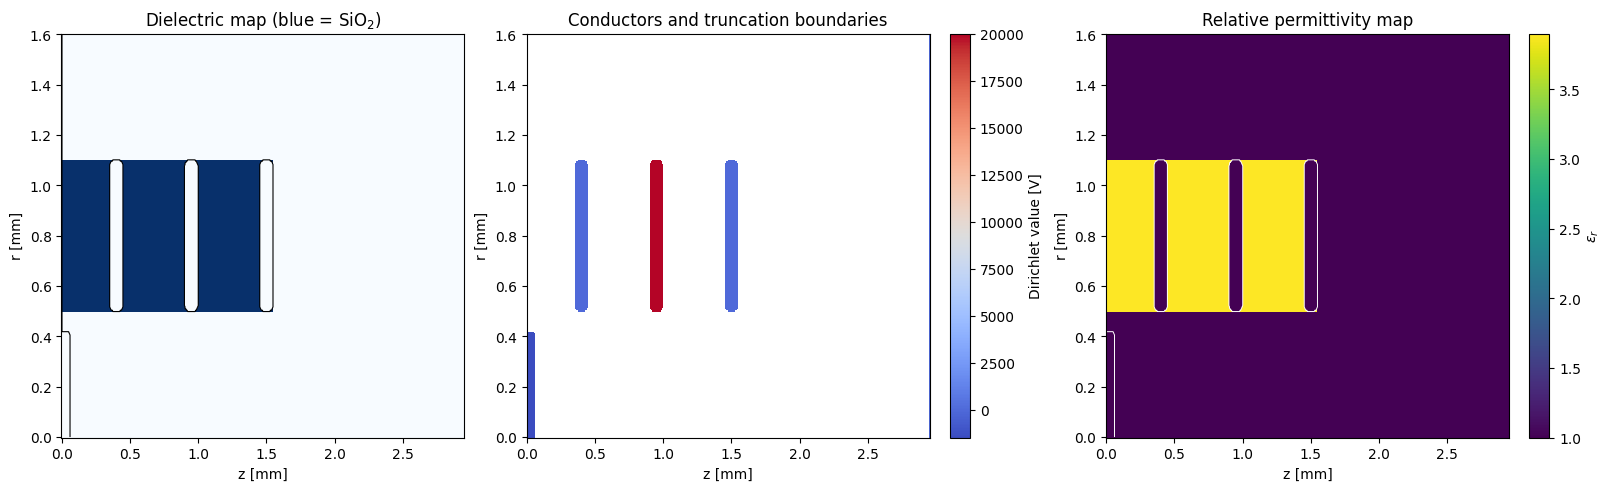

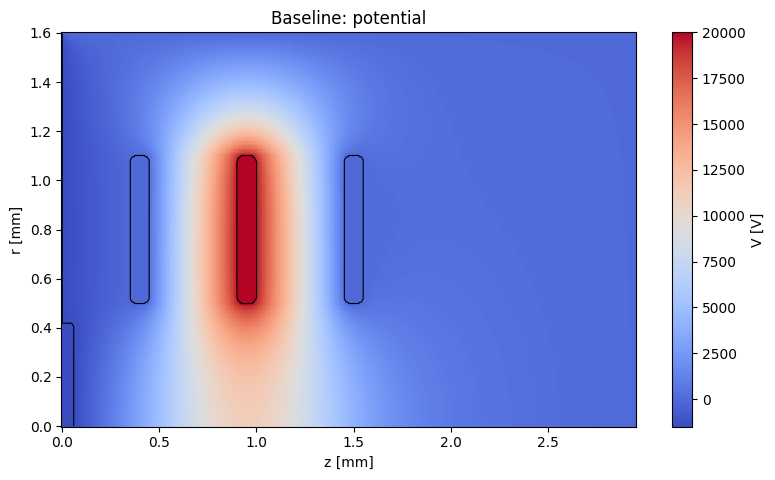

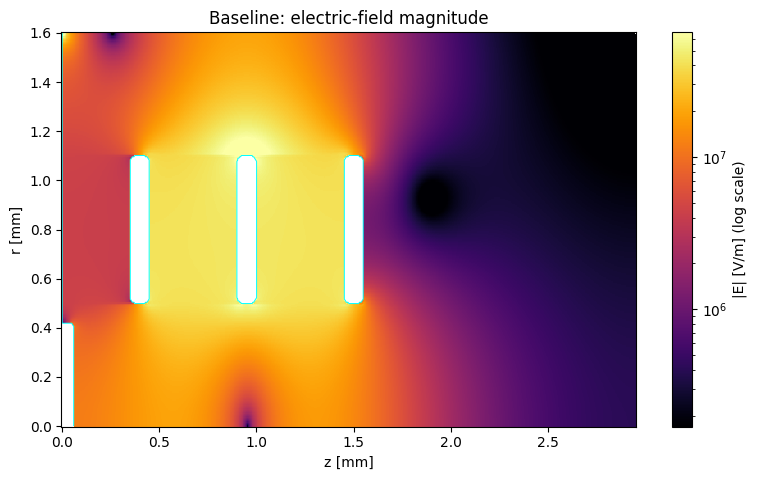

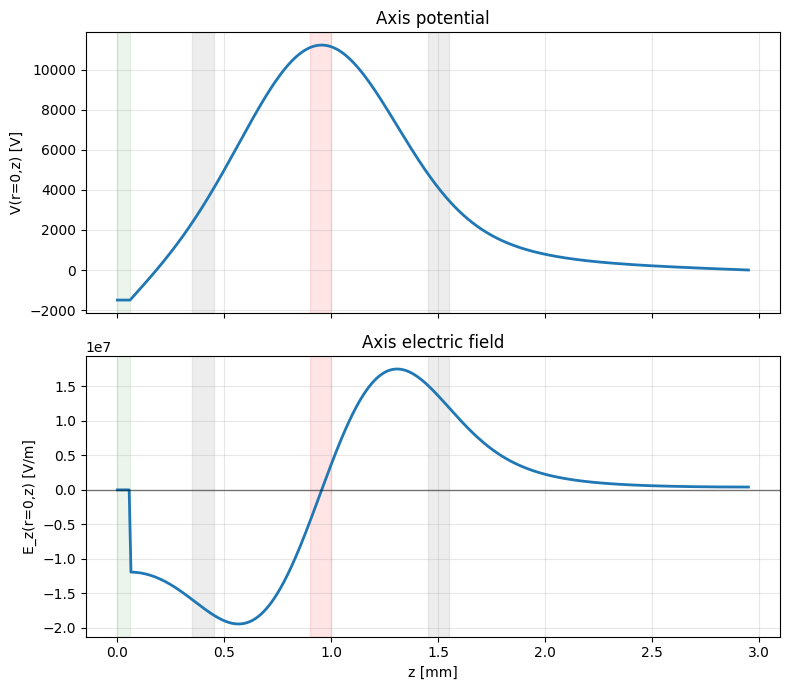

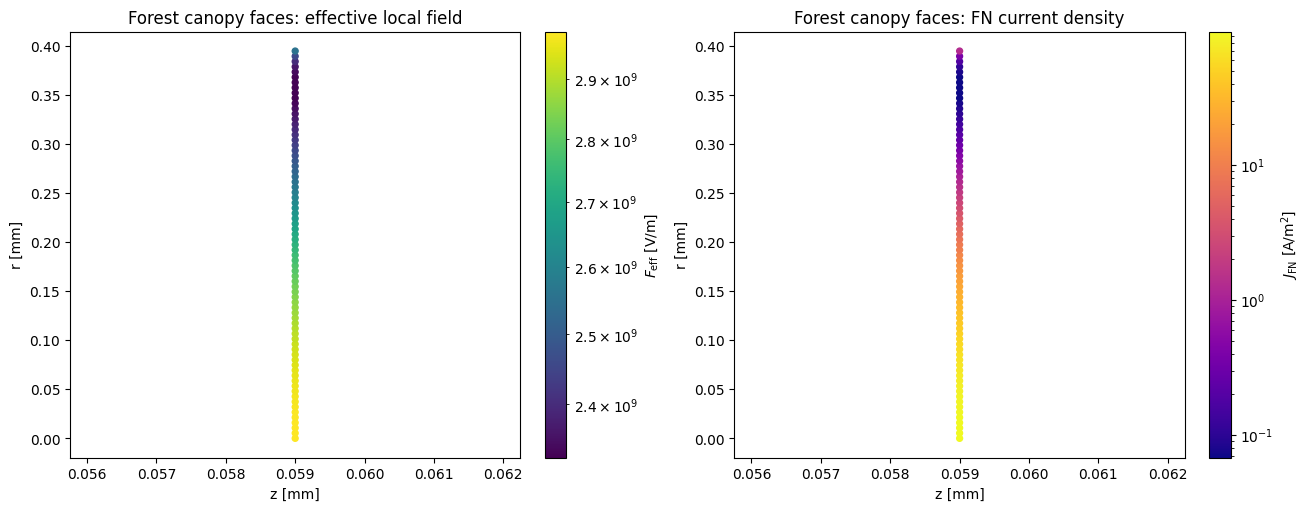

Emission-face samples: 75
Effective emitting area fraction eta_emit = 1.005e-03
Total FN current estimate I_total = 5.140e-09 A


In [25]:

plot_geometry_maps(baseline["r"], baseline["z"], baseline["geom"])
plot_potential_map(baseline, "Baseline: potential")
plot_field_map(baseline, "Baseline: electric-field magnitude")
plot_axis_profiles(baseline)
plot_forest_emission_faces(baseline["emission"])



## Boundary-sensitivity study

The purpose of this study is to check whether the outer truncation boundaries are far enough away that the electrostatic observables of interest have become insensitive to domain enlargement.

We keep the baseline case as the reference and compare enlarged domains at approximately similar grid spacing.


In [26]:

def grid_from_target_spacing(R_case, zmax_case, dr_target, dz_target):
    Nr_case = int(np.ceil(R_case / dr_target)) + 1
    Nz_case = int(np.ceil(zmax_case / dz_target)) + 1
    return Nr_case, Nz_case


boundary_report = None
boundary_results = {}

if RUN_BOUNDARY_STUDY:
    dr_target = baseline["dr"]
    dz_target = baseline["dz"]

    for name, (R_case, zextra_case) in boundary_cases.items():
        zmax_case = z3_end + zextra_case
        Nr_case, Nz_case = grid_from_target_spacing(R_case, zmax_case, dr_target, dz_target)

        print(f"Running boundary case: {name:>11s} | "
              f"R_outer = {R_case*1e3:.3f} mm | z_extra = {zextra_case*1e3:.3f} mm | "
              f"grid = ({Nr_case}, {Nz_case})")

        boundary_results[name] = build_case(
            R_outer_case=R_case,
            z_extra_case=zextra_case,
            Nr_case=Nr_case,
            Nz_case=Nz_case,
            params=params,
            run_iterative=False,
        )

    ref = boundary_results["baseline"]["observables"]
    rows = []
    for name, case in boundary_results.items():
        obs = case["observables"]
        rows.append({
            "case": name,
            "R_outer_mm": case["R_outer"] * 1e3,
            "z_extra_mm": case["z_extra"] * 1e3,
            "Nr": case["Nr"],
            "Nz": case["Nz"],
            "t_direct_s": case["t_direct"],
            "axisV_peak": obs["axisV_peak"],
            "axisV_peak_rel_diff_vs_baseline": rel_diff(ref["axisV_peak"], obs["axisV_peak"]),
            "axis_field_integral": obs["axis_field_integral"],
            "axis_field_integral_rel_diff_vs_baseline": rel_diff(ref["axis_field_integral"], obs["axis_field_integral"]),
            "forest_macroF_mean": obs["forest_macroF_mean"],
            "forest_macroF_mean_rel_diff_vs_baseline": rel_diff(ref["forest_macroF_mean"], obs["forest_macroF_mean"]),
            "forest_macroF_p95": obs["forest_macroF_p95"],
            "forest_macroF_p95_rel_diff_vs_baseline": rel_diff(ref["forest_macroF_p95"], obs["forest_macroF_p95"]),
            "I_FN_total": obs["I_FN_total"],
            "I_FN_total_rel_diff_vs_baseline": rel_diff(ref["I_FN_total"], obs["I_FN_total"]),
        })

    boundary_report = pd.DataFrame(rows)
    display(boundary_report)

    electrostatic_pass = (
        (boundary_report["axisV_peak_rel_diff_vs_baseline"].fillna(0) <= tol_boundary_axisV_peak).all()
        and (boundary_report["axis_field_integral_rel_diff_vs_baseline"].fillna(0) <= tol_boundary_axis_field_integral).all()
        and (boundary_report["forest_macroF_mean_rel_diff_vs_baseline"].fillna(0) <= tol_boundary_forest_macroF_mean).all()
        and (boundary_report["forest_macroF_p95_rel_diff_vs_baseline"].fillna(0) <= tol_boundary_forest_macroF_p95).all()
    )

    print()
    print("Boundary-study electrostatic pass/fail:")
    print("PASS" if electrostatic_pass else "NOT YET PASSING")


Running boundary case:    baseline | R_outer = 1.600 mm | z_extra = 1.400 mm | grid = (301, 701)
Running boundary case:    larger_r | R_outer = 2.000 mm | z_extra = 1.400 mm | grid = (376, 701)
Running boundary case:    larger_z | R_outer = 1.600 mm | z_extra = 2.100 mm | grid = (301, 868)
Running boundary case: larger_both | R_outer = 2.000 mm | z_extra = 2.100 mm | grid = (376, 868)


,case,R_outer_mm,z_extra_mm,Nr,Nz,t_direct_s,axisV_peak,axisV_peak_rel_diff_vs_baseline,axis_field_integral,axis_field_integral_rel_diff_vs_baseline,forest_macroF_mean,forest_macroF_mean_rel_diff_vs_baseline,forest_macroF_p95,forest_macroF_p95_rel_diff_vs_baseline,I_FN_total,I_FN_total_rel_diff_vs_baseline
0,baseline,1.6,1.4,301,701,5.452438,11233.942982,0.000000,-2022.184982,0.000000,1.076486e+07,0.000000,1.191064e+07,0.000000,5.139902e-09,0.000000
1,larger_r,2.0,1.4,376,701,8.827665,11241.785879,0.000698,-2110.252731,0.043551,1.077082e+07,0.000554,1.191742e+07,0.000570,5.218842e-09,0.015358
2,larger_z,1.6,2.1,301,868,7.539905,11227.943249,0.000534,-2047.530521,0.012534,1.078097e+07,0.001497,1.192897e+07,0.001539,5.358371e-09,0.042505
3,larger_both,2.0,2.1,376,868,10.804543,11236.387868,0.000218,-2172.321423,0.074245,1.078700e+07,0.002057,1.193583e+07,0.002115,5.441320e-09,0.058643



Boundary-study electrostatic pass/fail:
NOT YET PASSING


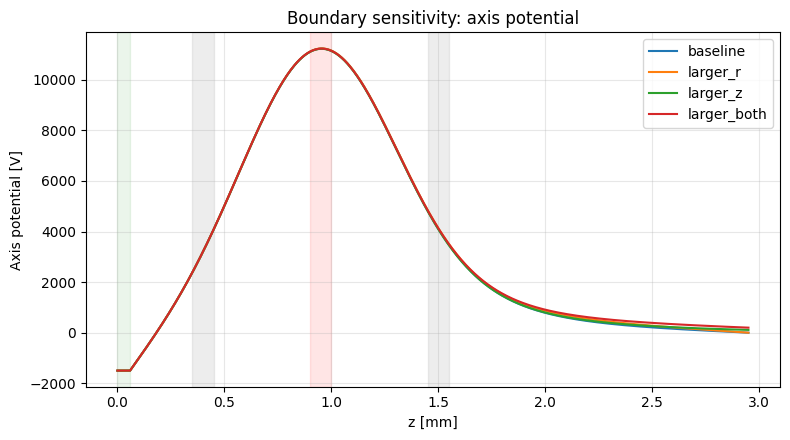

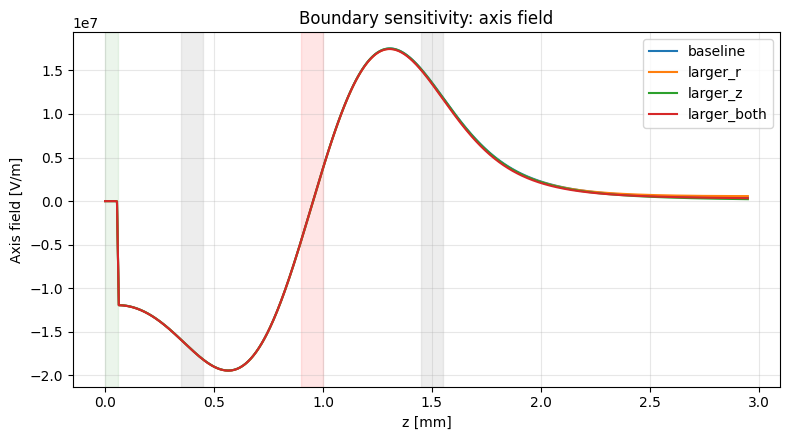

In [27]:

if RUN_BOUNDARY_STUDY:
    z_common = boundary_results["baseline"]["z"]

    plt.figure(figsize=(8, 4.5))
    for name, case in boundary_results.items():
        V_axis_interp = np.interp(z_common, case["z"], case["V_direct"][0, :])
        plt.plot(z_common * 1e3, V_axis_interp, label=name)
    draw_electrode_spans(plt.gca())
    plt.axvspan(0.0, h_forest * 1e3, color="green", alpha=0.08)
    plt.xlabel("z [mm]")
    plt.ylabel("Axis potential [V]")
    plt.title("Boundary sensitivity: axis potential")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig("figures/boundary_study_axis_potential.pdf", bbox_inches='tight', dpi=300)
    plt.show()

    plt.figure(figsize=(8, 4.5))
    for name, case in boundary_results.items():
        Ez_axis_interp = np.interp(z_common, case["z"], case["Ez_direct"][0, :])
        plt.plot(z_common * 1e3, Ez_axis_interp, label=name)
    draw_electrode_spans(plt.gca())
    plt.axvspan(0.0, h_forest * 1e3, color="green", alpha=0.08)
    plt.xlabel("z [mm]")
    plt.ylabel("Axis field [V/m]")
    plt.title("Boundary sensitivity: axis field")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig("figures/boundary_study_axis_field.pdf", bbox_inches='tight', dpi=300)
    plt.show()



## Mesh-refinement study

This study checks how the main electrostatic observables and axis profiles evolve with grid refinement.

The **fine** grid is used as the reference when available.


In [28]:
mesh_report = None
mesh_results = {}

if RUN_MESH_STUDY:
    for name, (Nr_case, Nz_case) in mesh_grids.items():
        print(f"Running mesh case: {name:>6s} | grid = ({Nr_case}, {Nz_case})")
        mesh_results[name] = build_case(
            R_outer_case=R_outer,
            z_extra_case=z_extra,
            Nr_case=Nr_case,
            Nz_case=Nz_case,
            params=params,
            run_iterative=False,
        )

    # Use the finest available grid as the reference
    ref_name = "xfine" if "xfine" in mesh_results else ("fine" if "fine" in mesh_results else list(mesh_results.keys())[-1])
    ref_case = mesh_results[ref_name]
    ref_obs = ref_case["observables"]

    rows = []
    z_ref = ref_case["z"]
    V_axis_ref = np.interp(z_ref, ref_case["z"], ref_case["V_direct"][0, :])
    Ez_axis_ref = np.interp(z_ref, ref_case["z"], ref_case["Ez_direct"][0, :])

    for name, case in mesh_results.items():
        obs = case["observables"]
        V_axis_interp = np.interp(z_ref, case["z"], case["V_direct"][0, :])
        Ez_axis_interp = np.interp(z_ref, case["z"], case["Ez_direct"][0, :])

        rows.append({
            "case": name,
            "Nr": case["Nr"],
            "Nz": case["Nz"],
            "t_direct_s": case["t_direct"],
            "axisV_peak": obs["axisV_peak"],
            "axisV_peak_rel_diff_vs_ref": rel_diff(ref_obs["axisV_peak"], obs["axisV_peak"]),
            "axis_field_integral": obs["axis_field_integral"],
            "axis_field_integral_rel_diff_vs_ref": rel_diff(ref_obs["axis_field_integral"], obs["axis_field_integral"]),
            "forest_macroF_mean": obs["forest_macroF_mean"],
            "forest_macroF_mean_rel_diff_vs_ref": rel_diff(ref_obs["forest_macroF_mean"], obs["forest_macroF_mean"]),
            "forest_macroF_p95": obs["forest_macroF_p95"],
            "forest_macroF_p95_rel_diff_vs_ref": rel_diff(ref_obs["forest_macroF_p95"], obs["forest_macroF_p95"]),
            "I_FN_total": obs["I_FN_total"],
            "I_FN_total_rel_diff_vs_ref": rel_diff(ref_obs["I_FN_total"], obs["I_FN_total"]),
            "axisV_profile_relL2_vs_ref": rel_l2(V_axis_ref, V_axis_interp),
            "axisEz_profile_relL2_vs_ref": rel_l2(Ez_axis_ref, Ez_axis_interp),
        })

    mesh_report = pd.DataFrame(rows)
    display(mesh_report)

    # -----------------------------
    # Pass/fail logic:
    # only require the last two refinement levels to agree
    # -----------------------------
    ordered_names = [k for k in ["coarse", "medium", "fine", "xfine"] if k in mesh_results]
    if len(ordered_names) < 2:
        raise ValueError("Need at least two mesh levels for a refinement study.")

    check_names = ordered_names[-2:]   # e.g. ["fine","xfine"] or ["medium","fine"]
    check_report = mesh_report[mesh_report["case"].isin(check_names)].copy()

    electrostatic_pass = (
        (check_report["axisV_peak_rel_diff_vs_ref"].fillna(0) <= tol_mesh_axisV_peak).all()
        and (check_report["axis_field_integral_rel_diff_vs_ref"].fillna(0) <= tol_mesh_axis_field_integral).all()
        and (check_report["forest_macroF_mean_rel_diff_vs_ref"].fillna(0) <= tol_mesh_forest_macroF_mean).all()
        and (check_report["forest_macroF_p95_rel_diff_vs_ref"].fillna(0) <= tol_mesh_forest_macroF_p95).all()
    )

    print()
    print(f"Reference grid: {ref_name}")
    print(f"Pass/fail checked on: {check_names}")
    print("Mesh-study electrostatic pass/fail:")
    print("PASS" if electrostatic_pass else "NOT YET PASSING")

Running mesh case: coarse | grid = (121, 281)
Running mesh case: medium | grid = (181, 421)
Running mesh case:   fine | grid = (241, 561)
Running mesh case:  xfine | grid = (301, 701)


,case,Nr,Nz,t_direct_s,axisV_peak,axisV_peak_rel_diff_vs_ref,axis_field_integral,axis_field_integral_rel_diff_vs_ref,forest_macroF_mean,forest_macroF_mean_rel_diff_vs_ref,forest_macroF_p95,forest_macroF_p95_rel_diff_vs_ref,I_FN_total,I_FN_total_rel_diff_vs_ref,axisV_profile_relL2_vs_ref,axisEz_profile_relL2_vs_ref
0,coarse,121,281,0.482946,11016.419542,0.019363,-2029.065534,0.003403,1.059934e+07,0.015376,1.177101e+07,0.011723,3.723604e-09,0.275550,0.016521,0.042680
1,medium,181,421,1.045478,11083.173317,0.013421,-2035.736206,0.006701,1.065954e+07,0.009783,1.178501e+07,0.010547,3.918058e-09,0.237717,0.011767,0.026129
2,fine,241,561,2.755914,11202.378565,0.002810,-2019.586613,0.001285,1.071082e+07,0.005020,1.186450e+07,0.003873,4.595651e-09,0.105887,0.002836,0.010080
3,xfine,301,701,5.173689,11233.942982,0.000000,-2022.184982,0.000000,1.076486e+07,0.000000,1.191064e+07,0.000000,5.139902e-09,0.000000,0.000000,0.000000



Reference grid: xfine
Pass/fail checked on: ['fine', 'xfine']
Mesh-study electrostatic pass/fail:
PASS


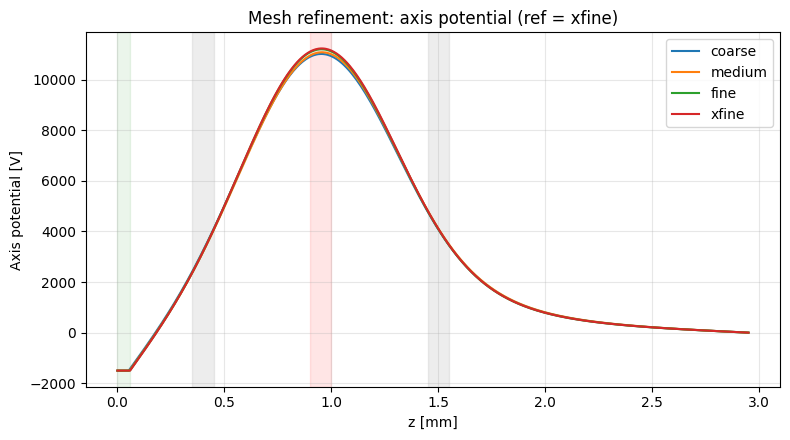

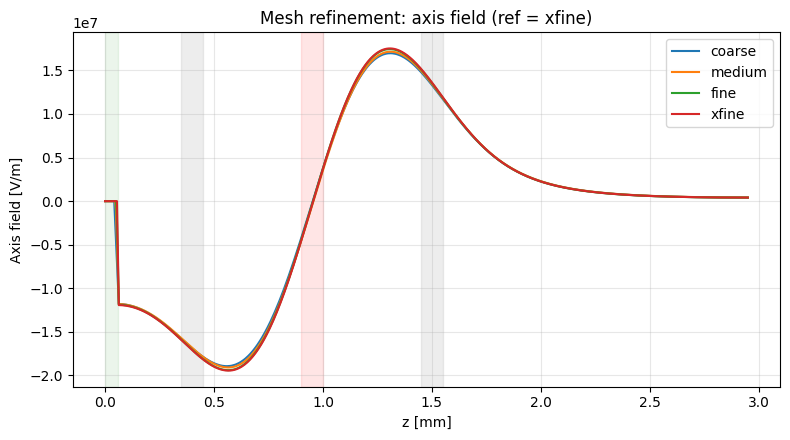

In [29]:
if RUN_MESH_STUDY:
    ref_name = "xfine" if "xfine" in mesh_results else ("fine" if "fine" in mesh_results else list(mesh_results.keys())[-1])
    z_ref = mesh_results[ref_name]["z"]

    plt.figure(figsize=(8, 4.5))
    for name, case in mesh_results.items():
        V_axis_interp = np.interp(z_ref, case["z"], case["V_direct"][0, :])
        plt.plot(z_ref * 1e3, V_axis_interp, label=name)
    draw_electrode_spans(plt.gca())
    plt.axvspan(0.0, h_forest * 1e3, color="green", alpha=0.08)
    plt.xlabel("z [mm]")
    plt.ylabel("Axis potential [V]")
    plt.title(f"Mesh refinement: axis potential (ref = {ref_name})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig("figures/mesh_study_axis_potential.pdf", bbox_inches='tight', dpi=300)
    plt.show()

    plt.figure(figsize=(8, 4.5))
    for name, case in mesh_results.items():
        Ez_axis_interp = np.interp(z_ref, case["z"], case["Ez_direct"][0, :])
        plt.plot(z_ref * 1e3, Ez_axis_interp, label=name)
    draw_electrode_spans(plt.gca())
    plt.axvspan(0.0, h_forest * 1e3, color="green", alpha=0.08)
    plt.xlabel("z [mm]")
    plt.ylabel("Axis field [V/m]")
    plt.title(f"Mesh refinement: axis field (ref = {ref_name})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig("figures/mesh_study_axis_field.pdf", bbox_inches='tight', dpi=300)
    plt.show()


## Save outputs for the next trajectory notebook

The baseline solved arrays are saved so the next notebook can focus on electron tracing rather than rebuilding the electrostatics from scratch.


In [30]:

np.savez(
    "cnt_forest_einzel_baseline_arrays.npz",
    r=baseline["r"],
    z=baseline["z"],
    V_direct=baseline["V_direct"],
    Er_direct=baseline["Er_direct"],
    Ez_direct=baseline["Ez_direct"],
    E_direct=baseline["E_direct"],
)

if boundary_report is not None:
    boundary_report.to_csv("cnt_forest_boundary_report.csv", index=False)

if mesh_report is not None:
    mesh_report.to_csv("cnt_forest_mesh_report.csv", index=False)

print("Saved:")
print("  cnt_forest_einzel_baseline_arrays.npz")
if boundary_report is not None:
    print("  cnt_forest_boundary_report.csv")
if mesh_report is not None:
    print("  cnt_forest_mesh_report.csv")


Saved:
  cnt_forest_einzel_baseline_arrays.npz
  cnt_forest_boundary_report.csv
  cnt_forest_mesh_report.csv



## What this notebook now provides

### Milestone 1: Defensible electrostatics
Implemented here:
- explicit dielectric,
- refined electrode + oxide stack geometry,
- dense-forest macro emitter,
- boundary-sensitivity study,
- mesh-refinement study.

### Milestone 2: Emission and optics
Implemented here:
- CNT-forest macro emitter model,
- effective canopy FN coupling.

### What is still next
The next notebook can now do **electron tracing** through the saved fields, using:
- the solved \(V(r,z)\),
- the solved \(\mathbf{E}(r,z)\),
- and the effective forest emission distribution.

That is the natural next step.
